<a href="https://colab.research.google.com/github/Akash-Behera-123/DL-BasicProject/blob/main/Fashion_MNIST_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

# **Importing the dependencies**

In [4]:
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt


Data Curation

In [7]:
#Load and prepare the Fashion MNIST dataset
fashion_mnist = datasets.fashion_mnist
(train_images,train_labels),(test_images,test_labels) = fashion_mnist.load_data()

In [8]:
type(train_images)

numpy.ndarray

In [9]:
type(train_labels)

numpy.ndarray

In [10]:
print(len(train_images))

60000


In [11]:
print(len(train_labels))

60000


In [13]:
print(train_images[0].shape)

(28, 28)


In [14]:
print(train_images[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

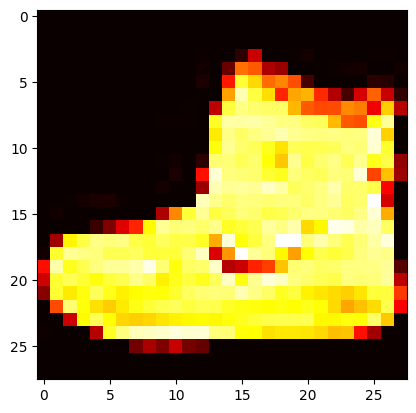

In [19]:
#display an image from the dataset
plt.imshow(train_images[0],cmap='hot')
plt.show()

In [20]:
print(train_labels[0])

9


class_name=['T-shirt/top'.'Trouser','pullover','dress','coat','sandal','shirt','sneaker','Bag','Ankle boot'.]

In [21]:
#Normalizing pixel value to be  between 0 and 1
train_images,test_images = train_images/255.0, test_images/255.0

In [22]:
#Reshape images to specify that its a single channel (grayscale)
train_images = train_images.reshape((train_images.shape[0],28,28,1))
test_images = test_images.reshape((test_images.shape[0],28,28,1))

#Convolutional Neural Network

In [24]:
model = models.Sequential()
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))


#Add dense layers on top
model.add(layers.Flatten())
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dense(10))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
 #Compile and train the model
 model.compile(optimizer='adam',loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
               metrics=["accuracy"])

In [26]:
history = model.fit(train_images,train_labels,epochs=5,validation_data=(test_images,test_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.8213 - loss: 0.4889 - val_accuracy: 0.8691 - val_loss: 0.3665
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8844 - loss: 0.3165 - val_accuracy: 0.8859 - val_loss: 0.3177
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8999 - loss: 0.2703 - val_accuracy: 0.8924 - val_loss: 0.2946
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9104 - loss: 0.2397 - val_accuracy: 0.8995 - val_loss: 0.2793
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9207 - loss: 0.2140 - val_accuracy: 0.8997 - val_loss: 0.2800


In [27]:
#Evaluate the model
test_loss, test_acc = model.evaluate(test_images,test_labels,verbose=2)
print('\nTest accuracy',test_acc)

313/313 - 2s - 5ms/step - accuracy: 0.8997 - loss: 0.2800

Test accuracy 0.8996999859809875


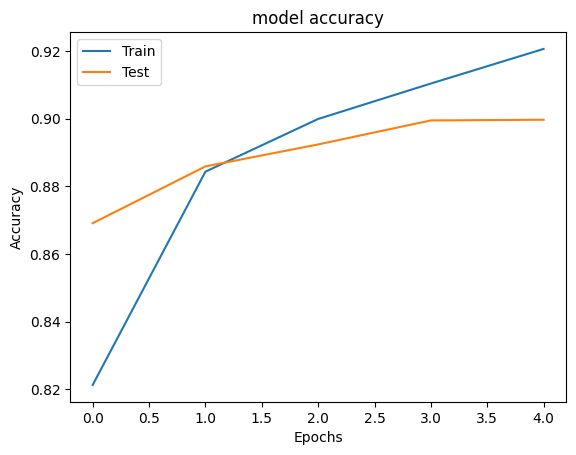

<function matplotlib.pyplot.show(close=None, block=None)>

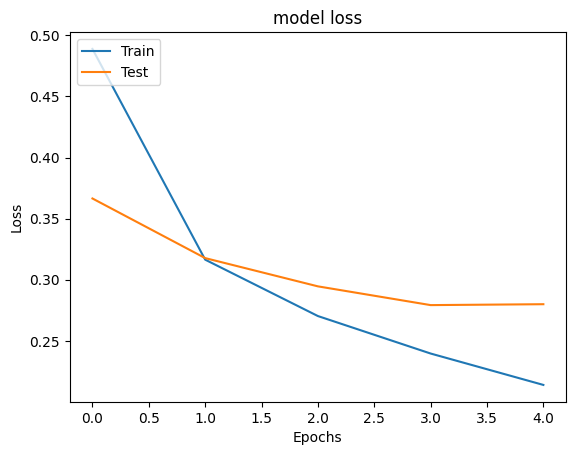

In [28]:
#Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['Train','Test'],loc='upper left')
plt.show()


#Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train','Test'],loc='upper left')
plt.show

In [29]:
model.save('trained_fashion_mnist_model.h5')